# 01 · C1 跑完了，但跟论文差 2.5 倍

论文 C1 说：在 nanoGPT 训练代码搜索上，LDM 让验证 BPB 的下降幅度是
LLM-only 反思的 **2.4 倍**。

我们用 GLM-5.3-Flash 照着跑，**量出来 0.97 倍**。


In [1]:
%matplotlib inline
import json, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 300, "savefig.dpi": 300, "font.size": 9,
    "axes.grid": True, "grid.alpha": .25,
    "axes.spines.top": False, "axes.spines.right": False,
})
R = Path("/lus/lfs1aip2/projects/public/u6gb/tasks/large-discovery-model/glm53_flash/results")

d = json.loads((R / "c1_repro.json").read_text())
print(f'baseline val_bpb = {d["baseline_val_bpb"]:.6f}')
for s, v in sorted(d["ratio_per_seed"].items()):
    print(f'  seed {s}: ratio = {v:.2f}x')
print(f'mean {d["ratio_mean"]:.2f}x   (paper: {d["paper_ratio"]}x)')

baseline val_bpb = 1.019308
  seed 1: ratio = 0.92x
  seed 2: ratio = 1.00x
  seed 3: ratio = 0.98x
mean 0.97x   (paper: 2.4x)


## 图 1 — 六条轨迹，A 组和 B 组几乎一样

A 组开 GP 引导，B 组关掉，其余全一样。

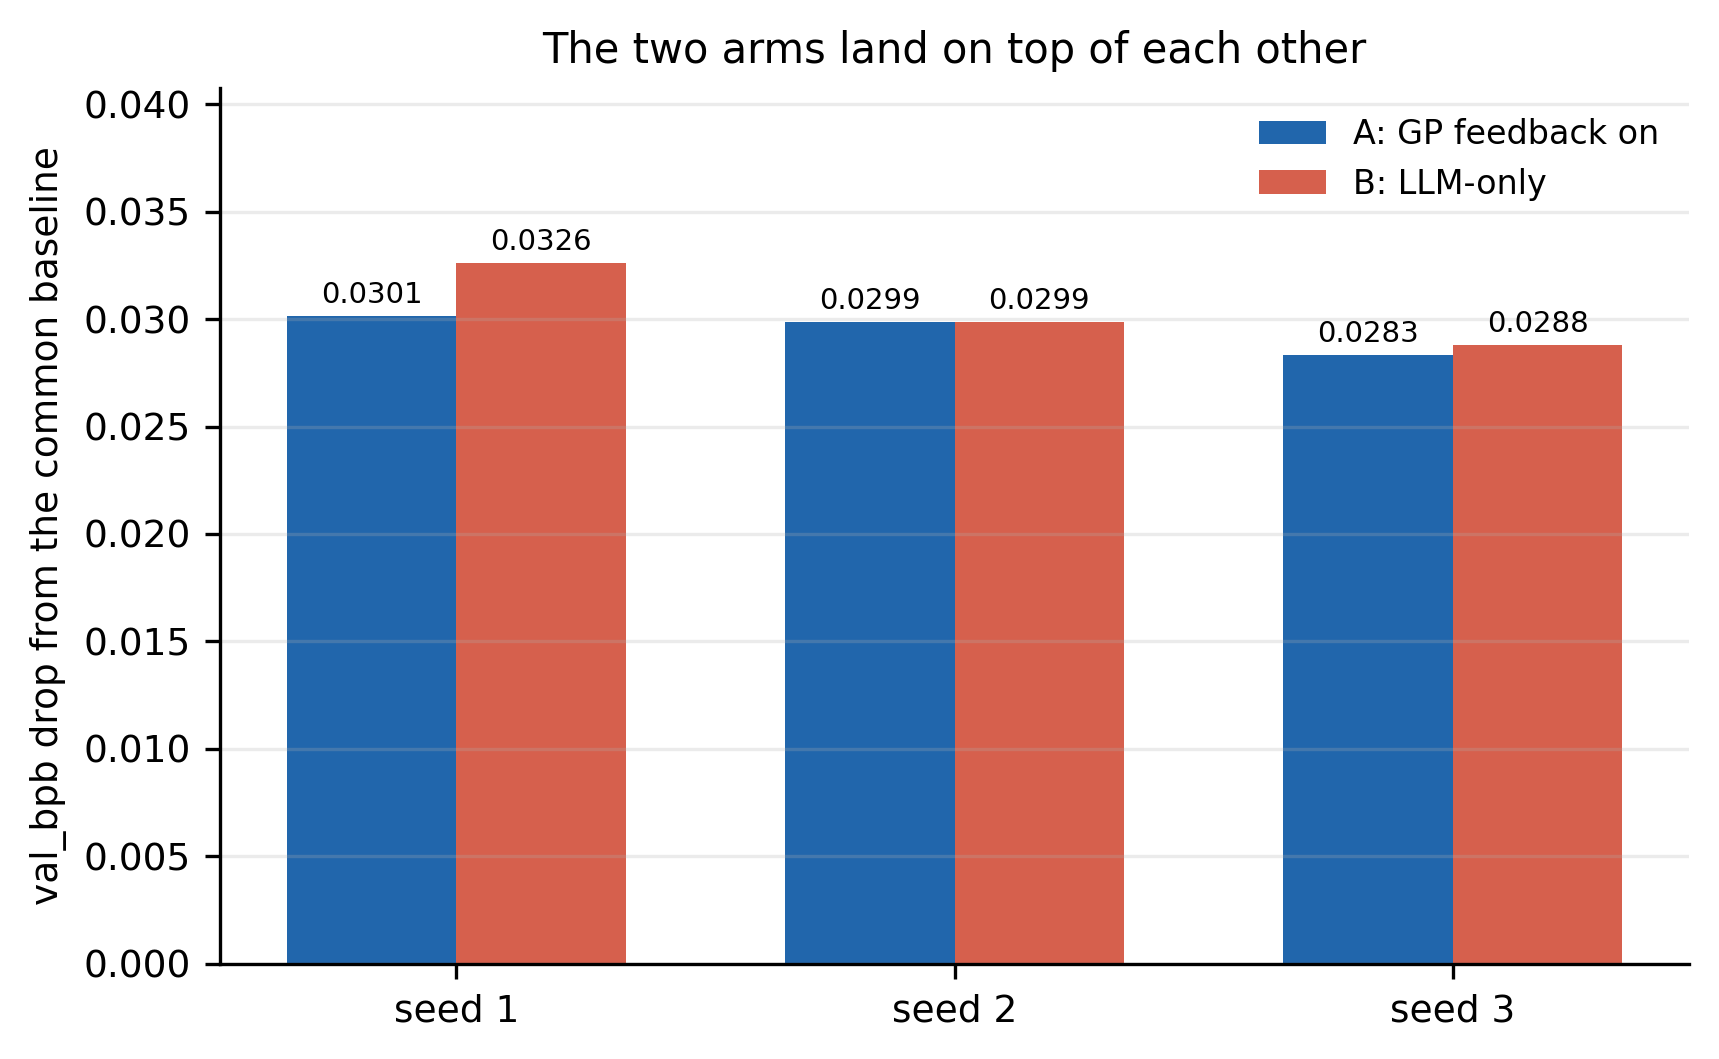

In [2]:
runs = d["runs"]
fig, ax = plt.subplots(figsize=(5.8, 3.6))
seeds = sorted({r["seed"] for r in runs})
w = .34
for i, (arm, col, lab) in enumerate([("A", "#2166ac", "A: GP feedback on"),
                                     ("B", "#d6604d", "B: LLM-only")]):
    vals = [next(r["delta"] for r in runs if r["arm"] == arm and r["seed"] == s) for s in seeds]
    ax.bar([s + (i - .5) * w for s in seeds], vals, width=w, color=col, label=lab)
    for s, v in zip(seeds, vals):
        ax.text(s + (i - .5) * w, v + .0006, f"{v:.4f}", ha="center", fontsize=7)
ax.set_xticks(seeds); ax.set_xticklabels([f"seed {s}" for s in seeds])
ax.set_ylabel("val_bpb drop from the common baseline")
ax.set_title("The two arms land on top of each other", fontsize=10)
ax.set_ylim(0, max(r["delta"] for r in runs) * 1.25)
ax.legend(frameon=False, fontsize=8); ax.grid(axis="x", alpha=0)
plt.tight_layout(); plt.show()

**怎么读**：每对柱子几乎一样高。GP 引导开不开，验证 BPB 的下降幅度看不出区别。

## 图 2 — 比值离论文有多远

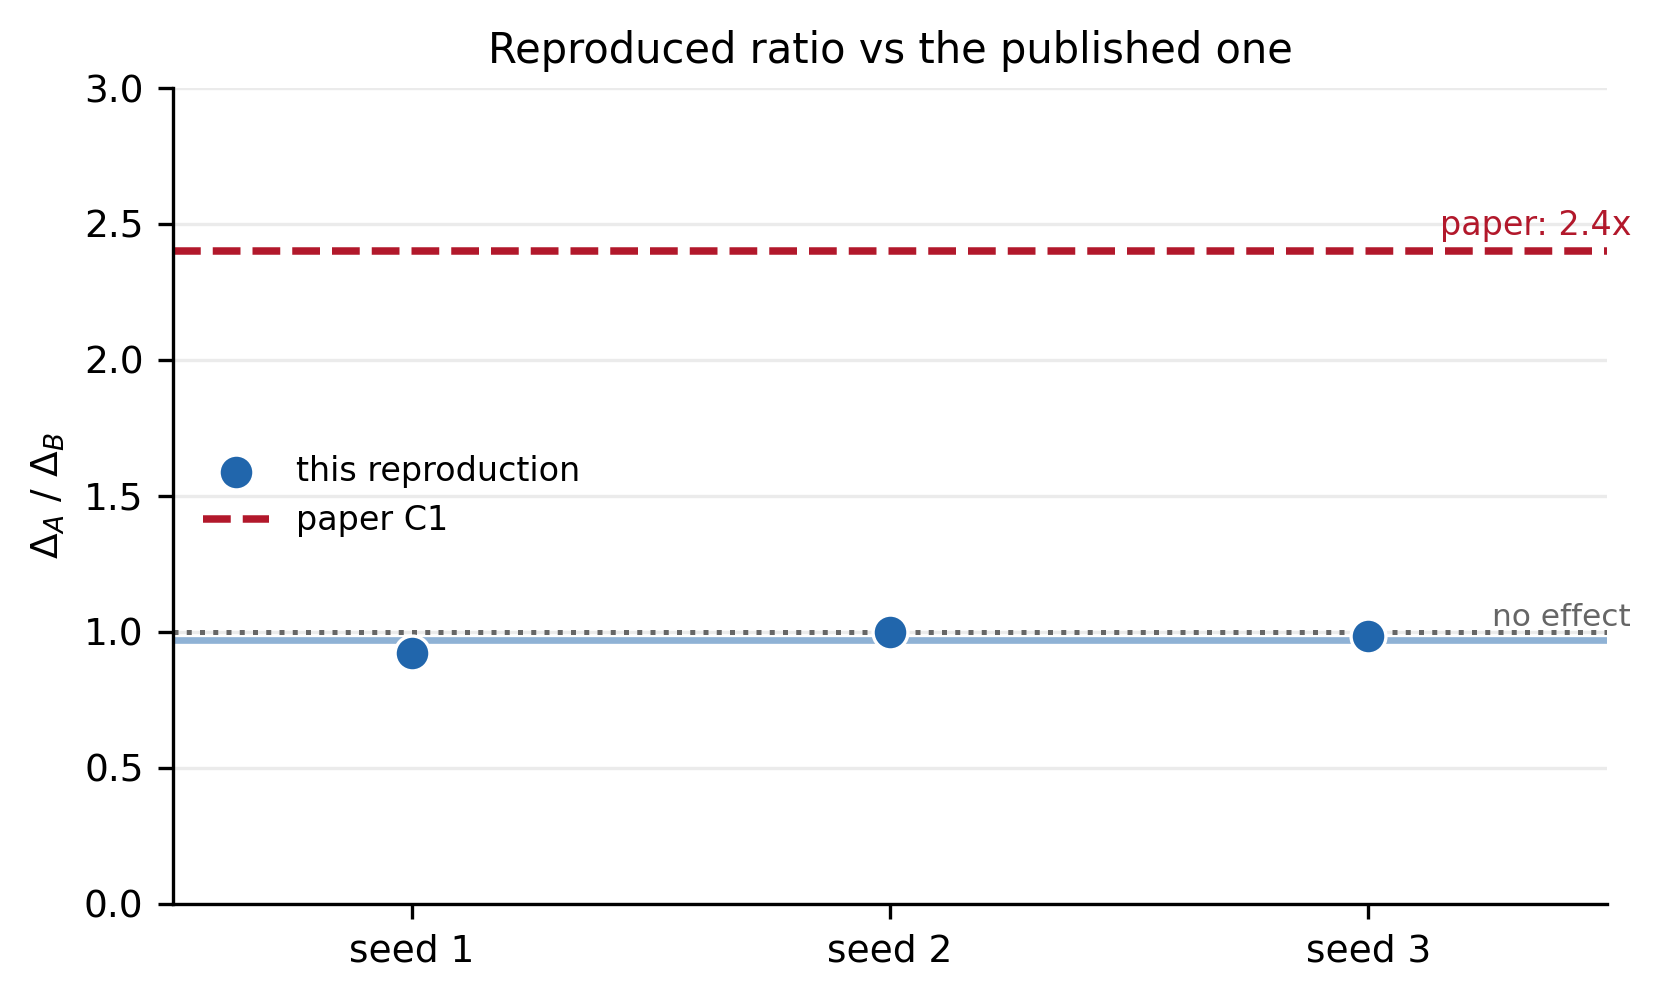

In [3]:
fig, ax = plt.subplots(figsize=(5.6, 3.4))
xs = sorted(d["ratio_per_seed"]); ys = [d["ratio_per_seed"][k] for k in xs]
ax.scatter(range(len(xs)), ys, s=70, color="#2166ac", zorder=3,
           edgecolors="white", linewidths=.8, label="this reproduction")
ax.axhline(d["ratio_mean"], ls="-", lw=1.6, color="#2166ac", alpha=.5)
ax.axhline(1.0, ls=":", lw=1.2, color="#666666")
ax.text(len(xs) - .45, 1.02, "no effect", fontsize=7.5, color="#666666", ha="right")
ax.axhline(d["paper_ratio"], ls="--", lw=1.8, color="#b2182b", label="paper C1")
ax.text(len(xs) - .45, d["paper_ratio"] + .06, f'paper: {d["paper_ratio"]}x',
        fontsize=8, color="#b2182b", ha="right")
ax.set_xticks(range(len(xs))); ax.set_xticklabels([f"seed {k}" for k in xs])
ax.set_xlim(-.5, len(xs) - .5); ax.set_ylim(0, d["paper_ratio"] * 1.25)
ax.set_ylabel(r"$\Delta_{A}\ /\ \Delta_{B}$")
ax.set_title("Reproduced ratio vs the published one", fontsize=10)
ax.legend(frameon=False, fontsize=8, loc="center left"); ax.grid(axis="x", alpha=0)
plt.tight_layout(); plt.show()

**怎么读**：三个点挤在 0.92–1.00 这一小段里，全都贴着「没有效果」那条虚线，
离论文那条红线很远。三个种子里只有一个（seed 2 的 1.00）勉强不算 A 组输。

## 数

单位是从共同基线（未改动的 `real_train.py`，实测 val_bpb 1.019308）算起的绝对下降。

In [4]:
pd.DataFrame([
    {"arm": r["arm"], "seed": r["seed"], "evaluations": r["n_evals"],
     "first eval": f'{r["first"]:.6f}', "best": f'{r["best"]:.6f}',
     "drop": f'{r["delta"]:.6f}'}
    for r in sorted(runs, key=lambda x: (x["arm"], x["seed"]))
]).style.hide(axis="index")

arm,seed,evaluations,first eval,best,drop
A,1,41,0.994296,0.989182,0.030126
A,2,44,0.994137,0.989434,0.029874
A,3,43,1.016950,0.990983,0.028325
B,1,37,1.075514,0.986707,0.032601
B,2,37,1.048066,0.989440,0.029868
B,3,39,1.046357,0.990497,0.028811


## 差距在哪，还不知道

跑是跑完了，但**没查为什么对不上**。三个可能，一个都没验：

**1. 模型不一样。** 论文用的提案模型和 GLM-5.3-Flash 不是一回事。
GP 后验能不能变成更好的候选，本来就取决于模型读不读得懂那段提示。

**2. 预算不够。** 论文 100 轮，我们 40 轮。GP 要先积累够观测才谈得上引导，
40 轮可能还在暖机阶段。这个可以直接测：把 A 组延长到 100 轮再看。

**3. 那个开关可能不是论文说的那件事。** 我们把「有没有经验代理」实现成
`--acquisition-feedback brief` vs `none`（GP 后验进不进提示）。读代码时确认过
`breadth × depth` 决定的是真评测次数、不是打分候选数，用它区分会让 A 组
多跑 7.7 倍评测 —— 那个坑躲开了。但 `acquisition-feedback` 是不是论文那条线，
只是从代码推的，没跟作者对过。

**下一步最便宜的是第 2 条**：同样的设置把轮数拉到 100，看比值动不动。
第 3 条得问作者。

## 有一点是确定的

**这不是「跑挂了」，是「跑通了但没效果」。** 六条轨迹全部完成，
每条 37–44 次有效评测，val_bpb 都从基线降下来了（0.028–0.033）。
两组都在正常工作，只是 GP 引导那组并没有更好。

三轮起跑暴露的四个缺陷都在正式跑之前修掉了：服务和实验分作业导致空跑、
`breadth×depth` 被误当成打分候选数、自设 `CUDA_VISIBLE_DEVICES` 指向不存在的卡、
起服漏了 tool calling 标志导致每个候选吃 400。所以这批数不是在坏管道上跑出来的。